##### ### The University of Melbourne, School of Computing and Information Systems

# COMP30027 Machine Learning, 2026 Semester 1

## Assignment 1: Income Classification with Naïve Bayes


**Student ID:** `1615557`


This iPython notebook is a template which you will use for your Assignment 1 submission.

**NOTE: YOU SHOULD ADD YOUR RESULTS, GRAPHS, AND FIGURES FROM YOUR OBSERVATIONS IN THIS FILE TO YOUR REPORT (the PDF file).** Results, figures, etc. which appear in this file but are NOT included in your report will not be marked.

**Adding proper comments to your code is MANDATORY. **


## 1. Supervised model training


In [12]:
import pandas as pd
import numpy as np
from collections import defaultdict as dd
from scipy.stats import norm
import matplotlib.pyplot as plt
import math
import copy
import pickle
import os


def read_and_clean_df(filename):
    """
    Takes in a csv file and reads it into a pandas DataFrame, then cleans it by
    dropping NaN rows and mapping incomes to binary classes.
    """
    df = pd.read_csv(f"./datasets/{filename}")
    df = df.dropna().copy()
    df["income"] = df["income"].copy().map({"<=50K": 0, ">50K": 1})
    return df


# Load all the dfs in at once so I can save pandas the effort of reading these in every time I run nbs

cleaned_df = read_and_clean_df("adult_supervised_train.csv")

test_set_df = read_and_clean_df("adult_test.csv")

unlabelled_df = pd.read_csv("./datasets/adult_unlabelled.csv")
unlabelled_df = unlabelled_df.dropna().copy()

In [13]:
def create_useful_arrays(df):
    """
    Creates arrays for features and classes that are useful throughout the project.
    """
    classes = df["income"].unique()
    categorical_features = df.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
    continuous_features = (
        df.select_dtypes(include=[np.number]).drop(columns=["income"]).columns.tolist()
    )
    return classes, categorical_features, continuous_features


def calculate_categorical_likelihood(count_cjv, alpha, N_c, K_j):
    """
    Calculates the categorical likelihood of an instance having attribute j equal to value v given it is class c.
    """
    return (count_cjv + alpha) / (N_c + alpha * K_j)


def build_initial_params(df: pd.DataFrame, alpha: float):
    """
    Builds the initial parameters dictionary, a way of keeping all information about the dataframe in one
    central place.
    """
    classes, categorical_features, continuous_features = create_useful_arrays(df)

    # Group by income, sorting into classes 0 and 1, and then find the mean and standard dev of each of the columns where those
    # features are continuous. grouped_stats is a MultiIndex
    grouped_stats = df.groupby("income")[continuous_features].agg(["mean", "std"])
    # This moves the feature from part of the column to part of the row, meaning we can now index (class_c, feature_x)
    # and get mean and standard dev for that combination
    stacked_stats = grouped_stats.stack(level=0, future_stack=True)
    # Convert the MultiIndex cleanly into a dictionary with keys (class_c, feature_x) and value being dictionaries
    # themselves, whose keys are "mean" and "std". Overall, it gives the mean and standard dev for the rows in the dataframe
    # with class = c and feature = x
    stats_dict = stacked_stats.to_dict("index")

    # This is the dictionary of distributions, ready to be used on new unseen test data points
    distribs_dict = dd(float)
    for key in stats_dict:
        mean = stats_dict[key]["mean"]
        std = stats_dict[key]["std"]
        distribs_dict[key] = norm(loc=mean, scale=std)

    # Now must find P(x_j=v | c) for every combination of attribute, attribute value, and class
    category_probabilities = dd(float)
    unseen_probabilities = {}

    # The keys are (class, attribute, attribute value) and the values are the probabilities of that
    class_counts = {c: (df["income"] == c).sum() for c in classes}
    for cf in categorical_features:
        # Creates a 2d table of counts of how many times we have income = c and cf = v
        counts = pd.crosstab(df["income"], df[cf])
        K_j = len(counts.columns)  # The number of distinct values for this feature
        for c in classes:
            unseen_probabilities[(c, cf)] = calculate_categorical_likelihood(
                count_cjv=0, alpha=alpha, N_c=class_counts[c], K_j=K_j
            )
            for av in counts.columns:
                count = counts.loc[
                    c, av
                ]  # Means the row label is c and the column label is av. This gives the # of occurrences where class is c and xj = av
                category_probabilities[(c, cf, av)] = calculate_categorical_likelihood(
                    count_cjv=count, alpha=alpha, N_c=class_counts[c], K_j=K_j
                )
    initial_params = {
        "classes": classes,
        "continuous_features": continuous_features,
        "categorical_features": categorical_features,
        "stats_dict": stats_dict,
        "distribs_dict": distribs_dict,
        "category_probabilities": category_probabilities,
        "unseen_probabilities": unseen_probabilities,
        "class_counts": class_counts,
        "total_training_rows": len(df),
        "unseen_cf_value_count": 0,
    }
    return initial_params


initial_params = build_initial_params(df=cleaned_df, alpha=1)


def find_most_predictive_att_val(c, ft, params: dict):
    """
    Finds the attribute value most predictive of a given class c, and returns that attribute and its
    R value as a dictionary.
    """
    highest_R_val = 0
    att = None

    unique_vals_for_ft = set(
        [key[2] for key in params["category_probabilities"].keys() if key[1] == ft]
    )

    for av in unique_vals_for_ft:
        p0 = params["category_probabilities"].get((0, ft, av), 1e-9)  # chance of <=50K
        p1 = params["category_probabilities"].get((1, ft, av), 1e-9)  # chance of >50K
        R_val = p1 / p0 if c == 1 else p0 / p1
        if R_val > highest_R_val:
            highest_R_val = R_val
            att = av
    return {"class": c, "attribute": att, "R_val": round(highest_R_val, 3)}


def find_highest_R_val_per_ft(params: dict):
    """
    Finds the highest posterior ratio R for each feature.
    """
    highest_R_val_per_ft = dd(dict)
    for cf in params["categorical_features"]:
        for c in params["classes"]:
            highest_R_val_per_ft[cf][c] = find_most_predictive_att_val(c, cf, params)
    return highest_R_val_per_ft


# --- Printing Most Predictive Attribute Value For Each Category ---
print("------- Printing Most Predictive Attribute Value for Each Category -------\n")
highest_R_val_per_ft = find_highest_R_val_per_ft(initial_params)
for cf in initial_params["categorical_features"]:
    for c in sorted(initial_params["classes"]):
        print(f"-Category {cf} and Class {c}-")
        most_predictive_att_val = highest_R_val_per_ft[cf][c]["attribute"]
        corresponding_r_val = highest_R_val_per_ft[cf][c]["R_val"]
        print(
            f"Attribute: {most_predictive_att_val:<12} | R-Value: {corresponding_r_val}\n"
        )


def print_5_most_predictive_fts(
    highest_R_val_per_ft: dict, params: dict, model_type: str
):
    """
    Prints the 5 most predictive feature values across all features.
    """
    highest_R_val_per_ft_list = [
        (key, val) for key, val in highest_R_val_per_ft.items()
    ]
    for c in params["classes"]:
        print(
            f"\n----- {model_type} Model: Top 5 Predictive Attributes for Class {c} -----\n"
        )
        sorted_list = sorted(
            highest_R_val_per_ft_list, key=lambda x: x[1][c]["R_val"], reverse=True
        )
        for feature_name, data in sorted_list[0:5]:
            attribute_name = data[c]["attribute"]
            r_val = data[c]["R_val"]
            print(
                f"Feature: {feature_name:<15} | Attribute: {attribute_name:<18} | R-Value: {r_val}"
            )


# --- Printing Top 5 Predictive Attributes for Each Class ---
print_5_most_predictive_fts(
    highest_R_val_per_ft, initial_params, model_type="Supervised"
)

prior_below_50k = (cleaned_df["income"] == 0).sum() / len(cleaned_df)
prior_above_50k = (cleaned_df["income"] == 1).sum() / len(cleaned_df)

print("\n----- Printing Priors -----\n")
print("prior_above_50k", round(prior_above_50k, 3))
print("prior_below_50k", round(prior_below_50k, 3))

print("\n----- Printing Continuous Feature Means and Std Devs -----")
for key in sorted(
    [key for key in initial_params["stats_dict"].keys()], key=lambda x: x[1]
):
    print()
    print(f"Class: {key[0]}, feature: {key[1]}")
    print(f"Mean: {round(initial_params['stats_dict'][key]['mean'], 3)}")
    print(f"Standard dev: {round(initial_params['stats_dict'][key]['std'], 3)}")


def find_bhattacharyya_coeff(mu1, mu2, sig1, sig2):
    return math.sqrt(2 * sig1 * sig2 / (sig1**2 + sig2**2)) * math.exp(
        -1 * (mu1 - mu2) ** 2 / (4 * (sig1**2 + sig2**2))
    )


def create_bha_coeffs_list(params: dict):
    bha_coeffs = []
    for cont_ft in params["continuous_features"]:
        if cont_ft == "fnlwgt":
            continue
        distrib_class_0 = params["distribs_dict"][(0, cont_ft)]
        distrib_class_1 = params["distribs_dict"][(1, cont_ft)]

        mu1 = distrib_class_0.mean()
        sig1 = distrib_class_0.std()

        mu2 = distrib_class_1.mean()
        sig2 = distrib_class_1.std()

        bha_coeff = find_bhattacharyya_coeff(mu1, mu2, sig1, sig2)
        bha_coeffs.append({"feature": cont_ft, "bha_coeff": round(bha_coeff, 3)})
    sorted_bha_coeffs_list = sorted(bha_coeffs, key=lambda x: x["bha_coeff"])
    return sorted_bha_coeffs_list


sorted_bha_coeffs_list = create_bha_coeffs_list(initial_params)
print(
    "\n----- Printing Top 3 Features With Least Similar Distributions From Class 0 to Class 1 By Bhattacharyya Coefficient -----"
)
print(sorted_bha_coeffs_list)

------- Printing Most Predictive Attribute Value for Each Category -------

-Category workclass and Class 0-
Attribute: Private      | R-Value: 1.167

-Category workclass and Class 1-
Attribute: Self-emp-inc | R-Value: 3.251

-Category education and Class 0-
Attribute: 9th          | R-Value: 6.629

-Category education and Class 1-
Attribute: Prof-school  | R-Value: 7.959

-Category marital-status and Class 0-
Attribute: Never-married | R-Value: 6.104

-Category marital-status and Class 1-
Attribute: Married-AF-spouse | R-Value: 4.288

-Category occupation and Class 0-
Attribute: Priv-house-serv | R-Value: 11.932

-Category occupation and Class 1-
Attribute: Exec-managerial | R-Value: 2.768

-Category relationship and Class 0-
Attribute: Own-child    | R-Value: 19.168

-Category relationship and Class 1-
Attribute: Wife         | R-Value: 2.745

-Category race and Class 0-
Attribute: Amer-Indian-Eskimo | R-Value: 2.267

-Category race and Class 1-
Attribute: Asian-Pac-Islander | R-Valu

In [14]:
# print(len(cleaned_df[(cleaned_df["income"] == 1) & (cleaned_df["age"] <= 25)]))
# print(len(cleaned_df[(cleaned_df["income"] == 1) & (cleaned_df["age"] > 26)]))
# print(len(cleaned_df[(cleaned_df["income"] == 1) & (cleaned_df["sex"] == "Male")]))
# print(len(cleaned_df[(cleaned_df["income"] == 1) & (cleaned_df["sex"] == "Female")]))
print(len(cleaned_df[(cleaned_df["income"] == 1) & (cleaned_df["education-num"] < 9)]))

103


## 2. Supervised model evaluation


In [15]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import math


def calculate_likelihood_continuous(params, c, ft, x):
    """
    Calculates the likelihood of an instance having attribute j being of value x, given that its class is c.
    """

    # get the normal distrib scaled for that class-feature combo with the mean and variance calculated from the data
    distrib = params["distribs_dict"][(c, ft)]
    likelihood = distrib.pdf(x)
    return max(
        likelihood, 1e-15
    )  # return tiny epsilon to prevent taking the log of 0 in case the probability is tiny


def get_soft_probabilities(instance: pd.Series, params: dict):
    leakproof_instance = instance.drop(labels=["income"], errors="ignore")
    posteriors_dict = {}
    for c in params["classes"]:
        likelihoods_list = []
        valid_features = params["continuous_features"] + params["categorical_features"]
        for ft in valid_features:
            av = leakproof_instance[ft]
            if ft in params["continuous_features"]:
                likelihood = calculate_likelihood_continuous(
                    params=params, c=c, ft=ft, x=av
                )
                likelihoods_list.append(likelihood)
            else:
                likelihood = params["category_probabilities"].get((c, ft, av), None)
                if likelihood is None:
                    likelihood = params["unseen_probabilities"][(c, ft)]
                    if c == params["classes"][0]:
                        other_class = params["classes"][1]
                        likelihood_in_other_class = params[
                            "category_probabilities"
                        ].get((other_class, ft, av), None)
                        if likelihood_in_other_class is None:
                            params["unseen_cf_value_count"] += 1
                likelihoods_list.append(likelihood)
        prior = params["class_counts"][c] / params["total_training_rows"]
        log_posterior = math.log(prior) + sum(math.log(l) for l in likelihoods_list)
        posteriors_dict[c] = log_posterior
    max_log_posterior = max(posteriors_dict.values())
    shifted_probs = {
        c: math.exp(log_post - max_log_posterior)
        for c, log_post in posteriors_dict.items()
    }
    sum_probs = sum(shifted_probs.values())
    normalised_soft_probs = {
        c: unnormalised_prob / sum_probs
        for c, unnormalised_prob in shifted_probs.items()
    }
    # algebra of how we can find log_likelihood:
    # log_likelihood = log(e^L1 + e^L2)
    # log_likelihood = log(e^M(e^{L1-M}+e^{L2-M}))
    # log_likelihood = log(e^M) + log(e^{L1-M}+e^{L2-M})
    # log_likelihood = M + log(e^{L1-M}+e^{L2-M})
    log_likelihood = max_log_posterior + math.log(sum_probs)
    return normalised_soft_probs, log_likelihood


def evaluate_test_instance(instance: pd.Series, params: dict):
    soft_probs, _ = get_soft_probabilities(instance, params)
    best_class = max(soft_probs, key=soft_probs.get)

    prob_class_0 = soft_probs[0]
    prob_class_1 = soft_probs[1]

    if prob_class_1 == 0.0:
        return best_class, float("inf")

    posterior_ratio = prob_class_0 / prob_class_1
    return best_class, posterior_ratio


# the slow part. This takes like 10 sec
test_set_df[["prediction", "posterior_ratio"]] = test_set_df.apply(
    lambda row: evaluate_test_instance(row, params=initial_params),
    axis=1,
    result_type="expand",
)


def report_metrics(y_true, y_pred, params):
    accuracy = accuracy_score(y_true, y_pred)
    print("accuracy:", round(accuracy, 3), "\n")

    print(classification_report(y_true, y_pred))

    print("unseen_cf_value_count:", params["unseen_cf_value_count"], "\n")

    print(confusion_matrix(y_true, y_pred), "\n")
    return accuracy


report_metrics(
    y_true=test_set_df["income"],
    y_pred=test_set_df["prediction"],
    params=initial_params,
)

post_ratios = test_set_df["posterior_ratio"]


# --- Printing Records with High Confidence of Class 0 and Class 1
confident_of_c0_records = test_set_df.sort_values(
    by="posterior_ratio", ascending=False
).iloc[0:3]
confident_of_c1_records = test_set_df.sort_values(
    by="posterior_ratio", ascending=True
).iloc[0:3]
test_set_df["R_dist_from_1"] = abs(test_set_df["posterior_ratio"] - 1)
near_decision_boundary_records = test_set_df.sort_values(by="R_dist_from_1").iloc[0:3]
print(
    "records with highest confidence that income is <=50K:\n", confident_of_c0_records
)
print("records with highest confidence that income is >50K:\n", confident_of_c1_records)
print("records near decision boundary:\n", near_decision_boundary_records)

accuracy: 0.83 

              precision    recall  f1-score   support

           0       0.85      0.93      0.89     11303
           1       0.72      0.52      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
weighted avg       0.82      0.83      0.82     15087

unseen_cf_value_count: 1 

[[10541   762]
 [ 1804  1980]] 

records with highest confidence that income is <=50K:
        age workclass  fnlwgt education  education-num marital-status  \
13228   18   Private  152044      10th              6  Never-married   
3216    17   Private  143791      10th              6  Never-married   
10584   17   Private  238628      11th              7  Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
13228  Other-service    Own-child  White  Female             0             0   
3216   Other-service    Own-child  Black  Female             0             0   
10584  Other

In [16]:
# print(cleaned_df["native-country"].unique())
# print(test_set_df["native-country"].unique())
# training_countries = cleaned_df["native-country"].unique()
# test_countries = test_set_df["native-country"].unique()
# un_present_countries = [c for c in test_countries if c not in training_countries]
# print(un_present_countries)

## 3. Extending the model with semi-supervised training


In [17]:
def expectation_step(unlabelled_df: pd.DataFrame, params: dict):
    # probs_series is a series of dictionaries with structure {0: prob_of_class_0, 1: prob_of_class_1}
    results_series = unlabelled_df.apply(
        lambda row: get_soft_probabilities(row, params),
        axis=1,
    )
    # probs_df is a dataframe with columns 0 and 1 and values of those columns being the probabilities
    probs_df = pd.DataFrame(
        [res[0] for res in results_series], index=unlabelled_df.index
    )
    total_log_likelihood = sum([res[1] for res in results_series])
    return probs_df, total_log_likelihood


def get_weighted_stats(cont_feature_values: pd.Series, weights: list):
    """
    Takes in a column of continuous feature values and a list of those instances' class weights, and calculates
    weighted means and standard deviations for each class based on expected class counts.
    """
    weighted_mean = np.average(cont_feature_values, weights=weights)
    weighted_variance = np.average(
        (cont_feature_values - weighted_mean) ** 2, weights=weights
    )
    weighted_std = math.sqrt(weighted_variance)
    weighted_std = max(weighted_std, 1e-9)  # if the std was 0, scipy.norm would crash
    return weighted_mean, weighted_std


def reestimate_continuous_params(
    labelled_df: pd.DataFrame,
    unlabelled_df: pd.DataFrame,
    probs_df: pd.DataFrame,
    params: dict,
    unlabelled_weight=1.0,
):
    """
    Updates the continuous distribution parameters in the params dictionary by recalculating them, using both hard
    labelled data and soft unlabelled data.
    """
    for c in params["classes"]:
        # put all the weights into one list
        labelled_weights = (labelled_df["income"] == c).astype(float)
        unlabelled_weights = probs_df[c] * unlabelled_weight
        all_weights = pd.concat([labelled_weights, unlabelled_weights])
        for ft in params["continuous_features"]:
            # put all the feature values into one list
            labelled_ft_vals = labelled_df[ft]
            unlabelled_ft_vals = unlabelled_df[ft]
            all_ft_vals = pd.concat([labelled_ft_vals, unlabelled_ft_vals])
            w_mean, w_std = get_weighted_stats(all_ft_vals, all_weights)
            # update the params dictionary with the new data from the expected class counts
            params["distribs_dict"][(c, ft)] = norm(loc=w_mean, scale=w_std)
    return params


def reestimate_categorical_params(
    labelled_df: pd.DataFrame,
    unlabelled_df: pd.DataFrame,
    probs_df: pd.DataFrame,
    params: dict,
    alpha: float,
    unlabelled_weight=1.0,
):
    merged_df = pd.concat([labelled_df, unlabelled_df])
    params["total_training_rows"] = len(merged_df)
    for c in params["classes"]:
        hard_count = (labelled_df["income"] == c).sum()
        soft_count = probs_df[c].sum() * unlabelled_weight
        params["class_counts"][c] = hard_count + soft_count
        for cf in params["categorical_features"]:
            unique_values = merged_df[cf].unique()
            K_j = len(unique_values)
            params["unseen_probabilities"][(c, cf)] = calculate_categorical_likelihood(
                count_cjv=0, alpha=alpha, N_c=params["class_counts"][c], K_j=K_j
            )
            for av in unique_values:
                hard_cjv_count = (
                    (labelled_df["income"] == c) & (labelled_df[cf] == av)
                ).sum()
                # find all the times when unlabelled_df[cf] == av, and then sum up the class probabilities
                true_false_mask = unlabelled_df[cf] == av
                # probs_df and unlabelled_df have matching indices
                soft_cjv_count = (
                    probs_df.loc[true_false_mask, c].sum() * unlabelled_weight
                )
                total_cjv_count = hard_cjv_count + soft_cjv_count
                params["category_probabilities"][(c, cf, av)] = (
                    calculate_categorical_likelihood(
                        count_cjv=total_cjv_count,
                        alpha=alpha,
                        N_c=params["class_counts"][c],
                        K_j=K_j,
                    )
                )
    return params


def run_em_algorithm(
    unlabelled_df: pd.DataFrame,
    labelled_df: pd.DataFrame,
    params: dict,
    alpha: float,
    do_print: bool,
    unlabelled_weight: float,
):
    ll_history = []
    convergence_threshold = 1e-2
    previous_log_likelihood = -float("inf")
    iteration_num = 1
    while True:
        # calculate probabilities of each class
        probs_df, log_likelihood = expectation_step(
            unlabelled_df=unlabelled_df, params=params
        )
        if do_print:
            print(
                f"Iteration {iteration_num} | Log-Likelihood: {round(log_likelihood, 2)}"
            )
        # update parameters
        params = reestimate_continuous_params(
            unlabelled_df=unlabelled_df,
            labelled_df=labelled_df,
            probs_df=probs_df,
            params=params,
            unlabelled_weight=unlabelled_weight,
        )
        params = reestimate_categorical_params(
            unlabelled_df=unlabelled_df,
            labelled_df=labelled_df,
            probs_df=probs_df,
            params=params,
            alpha=alpha,
            unlabelled_weight=unlabelled_weight,
        )
        ll_history.append(log_likelihood)
        # Takes 8m 18.5s to converge on my laptop
        if abs(log_likelihood - previous_log_likelihood) < convergence_threshold:
            print(f"\nConverged successfully after {iteration_num} iterations!")
            break
        previous_log_likelihood = log_likelihood

        iteration_num += 1
    return params, ll_history


def tune_hyperparams(
    unlabelled_df: pd.DataFrame,
    labelled_df: pd.DataFrame,
    alpha: float,
    do_print: bool,
    unlabelled_weight: float,
):
    from sklearn.model_selection import train_test_split

    practice_train_df, validation_df = train_test_split(
        labelled_df, test_size=0.2, random_state=1414
    )
    validation_df = validation_df.copy()
    fresh_params = build_initial_params(df=practice_train_df, alpha=alpha)

    mini_unlabelled_df = unlabelled_df.sample(frac=0.1, random_state=1414)

    trained_model_params, _ = run_em_algorithm(
        unlabelled_df=mini_unlabelled_df,
        labelled_df=practice_train_df,
        params=fresh_params,
        alpha=alpha,
        do_print=do_print,
        unlabelled_weight=unlabelled_weight,
    )
    trained_model_params["unseen_cf_value_count"] = 0
    validation_df[["prediction", "posterior_ratio"]] = validation_df.apply(
        lambda row: evaluate_test_instance(row, params=trained_model_params),
        axis=1,
        result_type="expand",
    )
    if do_print:
        accuracy = report_metrics(
            y_true=validation_df["income"],
            y_pred=validation_df["prediction"],
            params=trained_model_params,
        )
    else:
        accuracy = accuracy_score(
            y_true=validation_df["income"], y_pred=validation_df["prediction"]
        )
    return accuracy

In [ ]:
alphas_to_test = [0.5, 1.0, 1.5, 2.0]
unlabelled_weights_to_test = [0.1, 0.5, 1.0, 1.5, 2.0]
max_accuracy = 0
best_alpha = None
best_weight = None
for a in alphas_to_test:
    for w in unlabelled_weights_to_test:
        print(f"\n--- Testing Alpha: {a} and Unlabelled Weight: {w} ---")
        accuracy = tune_hyperparams(
            unlabelled_df=unlabelled_df,
            labelled_df=cleaned_df,
            alpha=a,
            unlabelled_weight=w,
            do_print=False,
        )
        print(f"Accuracy: {round(accuracy, 4)}")
        if accuracy > max_accuracy:
            max_accuracy = accuracy
            best_alpha = a
            best_weight = w
print(f"Best Alpha: {best_alpha}, best Weight: {best_weight}")

In [ ]:
best_alpha = 0.5
best_weight = 0.5
fresh_params = build_initial_params(df=cleaned_df, alpha=best_alpha)

_, ll_history = run_em_algorithm(
    unlabelled_df=unlabelled_df,
    labelled_df=cleaned_df,
    params=fresh_params,
    alpha=best_alpha,
    do_print=True,
    unlabelled_weight=best_weight,
)
plt.figure(figsize=(10, 6))
plt.plot(ll_history, marker="o", linestyle="-", color="b")
plt.title("EM Algorithm Convergence: Log-Likelihood over Iterations")
plt.xlabel("Iteration Number")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.show()  # Actually displays the graph!

## 4. Supervised model evaluation



--------------- Q1 Supervised Baseline ---------------


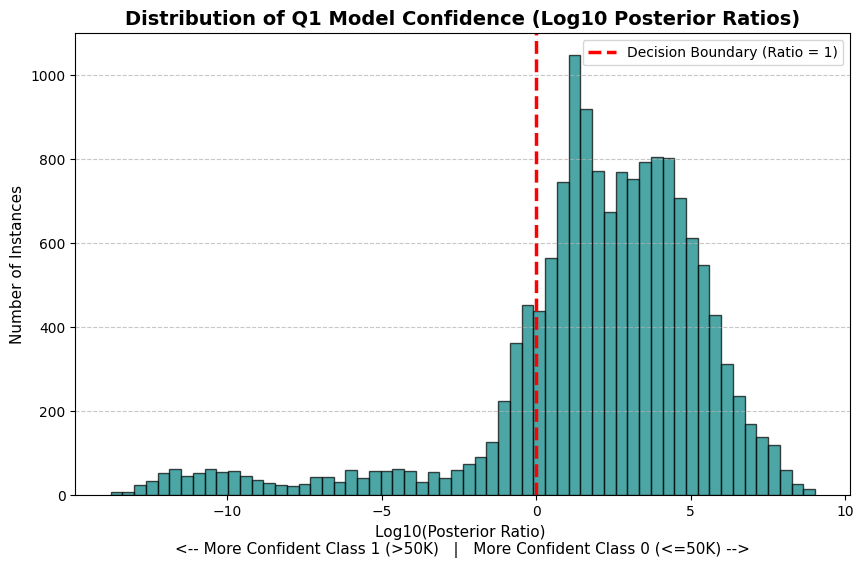

accuracy: 0.83 

              precision    recall  f1-score   support

           0       0.85      0.93      0.89     11303
           1       0.72      0.52      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
weighted avg       0.82      0.83      0.82     15087

unseen_cf_value_count: 1 

[[10541   762]
 [ 1802  1982]] 


----- Supervised Model: Top 5 Predictive Attributes for Class 0 -----

Feature: relationship    | Attribute: Own-child          | R-Value: 19.423
Feature: occupation      | Attribute: Priv-house-serv    | R-Value: 15.78
Feature: native-country  | Attribute: Peru               | R-Value: 8.181
Feature: education       | Attribute: 9th                | R-Value: 6.919
Feature: marital-status  | Attribute: Never-married      | R-Value: 6.112

----- Supervised Model: Top 5 Predictive Attributes for Class 1 -----

Feature: education       | Attribute: Prof-school        | R-Value: 8.002
Feature

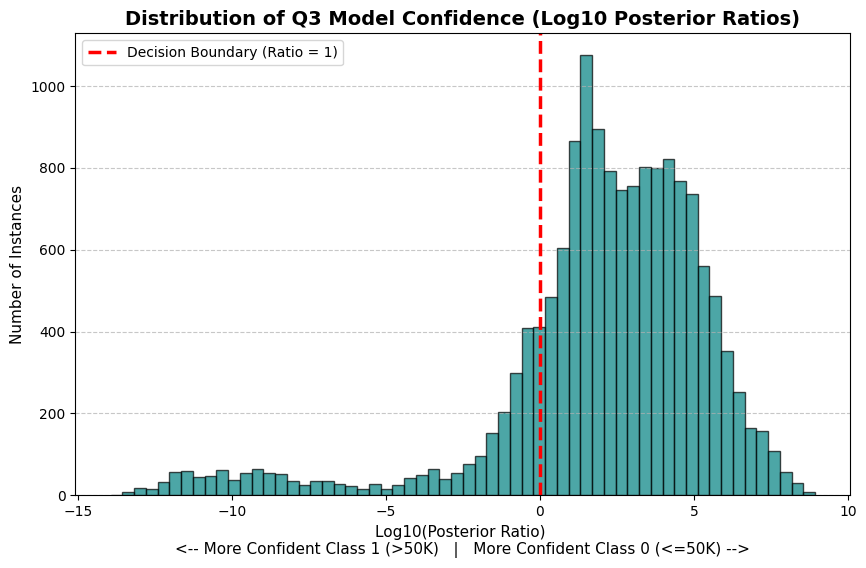


--- Q3 Continuous Feature Shifts ---
Class: 0, Feature: age | Mean: 37.119, Std: 13.596
Class: 1, Feature: age | Mean: 43.964, Std: 10.459
Class: 0, Feature: fnlwgt | Mean: 190257.988, Std: 106863.497
Class: 1, Feature: fnlwgt | Mean: 187635.323, Std: 100973.396
Class: 0, Feature: education-num | Mean: 9.644, Std: 2.401
Class: 1, Feature: education-num | Mean: 11.771, Std: 2.358
Class: 0, Feature: capital-gain | Mean: 177.445, Std: 1951.476
Class: 1, Feature: capital-gain | Mean: 4162.093, Std: 14703.475
Class: 0, Feature: capital-loss | Mean: 36.689, Std: 257.016
Class: 1, Feature: capital-loss | Mean: 275.161, Std: 683.876
Class: 0, Feature: hours-per-week | Mean: 39.566, Std: 11.921
Class: 1, Feature: hours-per-week | Mean: 45.783, Std: 10.685

--- Continuous Feature Shifts (Q1 vs Q3) ---
Bhattacharyya Overlap: 1.0000 = The EM algorithm changed nothing.
Class  | Feature         | Q1 Mean (Std)      | Q3 Mean (Std)      | Bhattacharyya Overlap    
-----------------------------------

0.8312454430967058

In [ ]:
best_alpha = 0.5
best_weight = 0.5


def plot_log_posterior_ratios(post_ratios, filename, title):
    # 1. Filter out the 'inf' values your function returns for 100% Class 0 confidence
    # (Matplotlib will crash if it tries to plot infinity)
    safe_ratios = post_ratios[post_ratios != float("inf")]

    # 2. Take the Log10 of the ratios to balance the scale
    log_ratios = np.log10(safe_ratios)

    # 3. Create the plot
    plt.figure(figsize=(10, 6))
    plt.hist(log_ratios, bins=60, color="teal", edgecolor="black", alpha=0.7)

    # 4. Draw a massive red dashed line exactly at the Decision Boundary (Log10(1) = 0)
    plt.axvline(
        x=0,
        color="red",
        linestyle="--",
        linewidth=2.5,
        label="Decision Boundary (Ratio = 1)",
    )

    # 5. Add professional labels
    plt.title(
        title,
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel(
        "Log10(Posterior Ratio) \n<-- More Confident Class 1 (>50K)   |   More Confident Class 0 (<=50K) -->",
        fontsize=11,
    )
    plt.ylabel("Number of Instances", fontsize=11)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # 6. Render it!
    plt.savefig(filename, bbox_inches="tight")
    plt.show()


def compare_q1_q3_continuous_shifts(q1_params: dict, q3_params: dict):
    print("\n--- Continuous Feature Shifts (Q1 vs Q3) ---")
    print("Bhattacharyya Overlap: 1.0000 = The EM algorithm changed nothing.")
    print(
        f"{'Class':<6} | {'Feature':<15} | {'Q1 Mean (Std)':<18} | {'Q3 Mean (Std)':<18} | {'Bhattacharyya Overlap':<25}"
    )
    print("-" * 85)

    for c in q1_params["classes"]:
        for ft in q1_params["continuous_features"]:
            if ft == "fnlwgt":
                continue

            dist_q1 = q1_params["distribs_dict"][(c, ft)]
            mu1, sig1 = dist_q1.mean(), dist_q1.std()

            dist_q3 = q3_params["distribs_dict"][(c, ft)]
            mu2, sig2 = dist_q3.mean(), dist_q3.std()

            bha_coeff = find_bhattacharyya_coeff(mu1, mu2, sig1, sig2)

            # Create formatted strings combining mean and standard deviation
            q1_str = f"{mu1:.2f} ({sig1:.2f})"
            q3_str = f"{mu2:.2f} ({sig2:.2f})"

            # Print the row using the new strings and wider spacing
            print(f"{c:<6} | {ft:<15} | {q1_str:<18} | {q3_str:<18} | {bha_coeff:.5f}")


def run_final_evaluation(
    unlabelled_df: pd.DataFrame,
    labelled_df: pd.DataFrame,
    test_set_df: pd.DataFrame,
    alpha: float,
):
    initial_params = build_initial_params(df=labelled_df, alpha=alpha)
    print("\n--------------- Q1 Supervised Baseline ---------------")
    initial_params["unseen_cf_value_count"] = 0  # Reset counter
    test_set_df[["prediction_Q1", "posterior_ratio_Q1"]] = test_set_df.apply(
        lambda row: evaluate_test_instance(row, params=initial_params),
        axis=1,
        result_type="expand",
    )
    post_ratios_Q1 = test_set_df["posterior_ratio_Q1"]
    plot_log_posterior_ratios(
        post_ratios_Q1,
        filename="./plots/R_vals_log_distrib_Q1.png",
        title="Distribution of Q1 Model Confidence (Log10 Posterior Ratios)",
    )

    report_metrics(
        y_true=test_set_df["income"],
        y_pred=test_set_df["prediction_Q1"],
        params=initial_params,
    )
    highest_R_val_per_ft_Q1 = find_highest_R_val_per_ft(initial_params)
    print_5_most_predictive_fts(
        highest_R_val_per_ft_Q1, initial_params, model_type="Supervised"
    )
    print("\n--------------- Running EM Algorithm ---------------")
    if os.path.exists("saved_q3_params.pkl"):
        print("--> Found saved model! Loading parameters instantly...")
        with open("saved_q3_params.pkl", "rb") as file:
            trained_model_params = pickle.load(file)
    else:
        print(
            "--> No saved model found. Training from scratch (this will take a few minutes)..."
        )
        params_for_em = copy.deepcopy(initial_params)

        trained_model_params, _ = run_em_algorithm(
            unlabelled_df=unlabelled_df,
            labelled_df=labelled_df,
            alpha=alpha,
            params=params_for_em,
            do_print=True,
            unlabelled_weight=best_weight,
        )

        # Save it to your hard drive!
        with open("saved_q3_params.pkl", "wb") as file:
            pickle.dump(trained_model_params, file)
        print("--> Model saved successfully!")

    print("\n--------------- Evaluating Semi-Supervised Q3 Model ---------------")
    trained_model_params["unseen_cf_value_count"] = 0  # Reset counter
    test_set_df[["prediction_Q3", "posterior_ratio_Q3"]] = test_set_df.apply(
        lambda row: evaluate_test_instance(row, params=trained_model_params),
        axis=1,
        result_type="expand",
    )
    post_ratios_Q3 = test_set_df["posterior_ratio_Q3"]
    plot_log_posterior_ratios(
        post_ratios_Q3,
        filename="./plots/R_vals_log_distribution_Q3.png",
        title="Distribution of Q3 Model Confidence (Log10 Posterior Ratios)",
    )
    compare_q1_q3_continuous_shifts(
        q1_params=initial_params, q3_params=trained_model_params
    )
    CHOSEN_ATTRIBUTE = "education"
    print(f"\n--- Categorical Feature Shifts: '{CHOSEN_ATTRIBUTE}' ---")

    # Print a table header for clean formatting
    print(
        f"{'Class':<6} | {'Education Level':<16} | {'Q1 Prob':<10} | {'Q3 Prob':<10} | {'Shift':<10}"
    )
    print("-" * 65)

    logical_education_order = [
        "Preschool",
        "1st-4th",
        "5th-6th",
        "7th-8th",
        "9th",
        "10th",
        "11th",
        "12th",
        "HS-grad",
        "Some-college",
        "Assoc-voc",
        "Assoc-acdm",
        "Bachelors",
        "Masters",
        "Prof-school",
        "Doctorate",
    ]

    for c in trained_model_params["classes"]:
        for av in logical_education_order:
            # Extract both probabilities (using .get() just to be completely safe against KeyErrors)
            q1_prob = initial_params["category_probabilities"].get(
                (c, CHOSEN_ATTRIBUTE, av), 0
            )
            q3_prob = trained_model_params["category_probabilities"].get(
                (c, CHOSEN_ATTRIBUTE, av), 0
            )

            # Calculate how much it changed
            shift = q3_prob - q1_prob

            # The <16 formatting ensures the columns line up perfectly, no matter how long the word is
            print(
                f"{c:<6} | {av:<16} | {q1_prob:<10.4f} | {q3_prob:<10.4f} | {shift:<10.4f}"
            )
    highest_R_val_per_ft = find_highest_R_val_per_ft(trained_model_params)
    print_5_most_predictive_fts(
        highest_R_val_per_ft, trained_model_params, model_type="Semi-Supervised"
    )
    accuracy = report_metrics(
        y_true=test_set_df["income"],
        y_pred=test_set_df["prediction_Q3"],
        params=trained_model_params,
    )
    return accuracy


run_final_evaluation(
    alpha=best_alpha,
    labelled_df=cleaned_df,
    test_set_df=test_set_df,
    unlabelled_df=unlabelled_df,
)